<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/ML_Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)  #redundant - useless feature


In [ ]:

X

array([[ 0.82321545, -0.11697552],
       [ 0.37514771, -0.73115232],
       [ 0.26947761, -0.7081059 ],
       [-4.98744874, -2.01199214],
       [ 0.4231285 ,  1.63493163],
       [-4.2289949 ,  0.15599044],
       [-5.18865382,  1.07782053],
       [ 0.7096287 ,  0.80626713],
       [ 0.06531501,  0.74859527],
       [-5.3563263 ,  0.75152794],
       [-5.17487315, -0.90114581],
       [-5.17644221, -0.1815243 ],
       [ 0.60202649, -2.98092432],
       [ 1.42960231,  1.20500136],
       [-5.22359581,  0.78302407],
       [ 1.01127528,  0.42968688],
       [ 0.48288133, -0.73229726],
       [-5.27614308, -0.83930476],
       [ 0.44163889,  0.83727062],
       [-5.167179  , -0.10255323],
       [-5.67316396,  0.65867001],
       [-5.4617787 ,  0.92649819],
       [-4.71348919,  0.10216193],
       [ 2.2344006 ,  0.46886454],
       [-4.61308761,  0.45432938],
       [ 1.2379403 ,  1.8613386 ],
       [-5.18419324, -0.79255991],
       [-4.43807529, -1.0004391 ],
       [-5.79725951,

In [ ]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [ ]:
import matplotlib.pyplot as plt


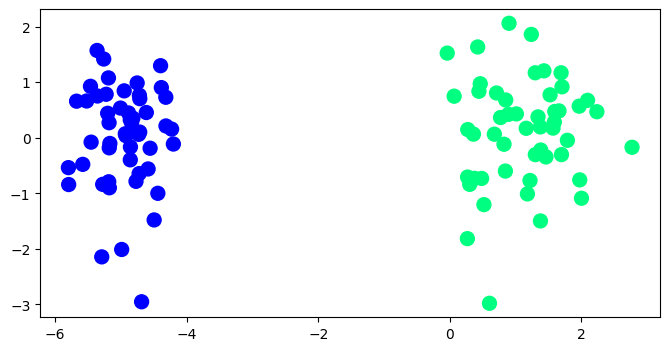

In [ ]:
plt.figure(figsize=(8,4))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)   # plotting both x feature


In [ ]:
def step(z):
    return 1 if z>0 else 0


def sigmoid(z):
    return 1/(1 + np.exp(-z)) # z = np.dot(X[j],weights) [ X.W ]

# https://medium.com/analytics-vidhya/derivative-of-log-loss-function-for-logistic-regression-9b832f025c2d

In [ ]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1) # assign x0 =1   [w0 + w1x1 + w2x2  = 0] [C+ Ax + By = 0] ,  #assign 1 to A,B,C
    weights = np.ones(X.shape[1]) # w0 w1 w2 = 1
    lr = 0.1

    for i in range(500): # epochs
        j = np.random.randint(0,100) # xi randomnly
        y_hat = np.dot(X[j],weights)     #value of z = b1x1+b2x2.....
        #y_hat = step(y_hat) # powerful step to perfor on the data predection sigmoid, relu, tanh activation fuction

        y_hat = step(y_hat)
        # if xi N and E wixi > 0
           # wn = wo (+)n*xi
        # if xi P and E wixi < 0
           # wn = wo (-)n*xi
        weights = weights + lr*(y[j]-y_hat)*X[j]    #?

    return weights[0],weights[1:] # intersept array of wieght

In [ ]:
intercept_,coef_ = perceptron(X,y)


In [ ]:
print(coef_) # w1 , w2
print(intercept_) # w0


[1.1204053  0.40381514]
1.2000000000000002


In [ ]:
m = -(coef_[0]/coef_[1]) # m = - A/B b = -C/B
b = -(intercept_/coef_[1])

# y = mx + b

In [ ]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b


(-3.0, 2.0)

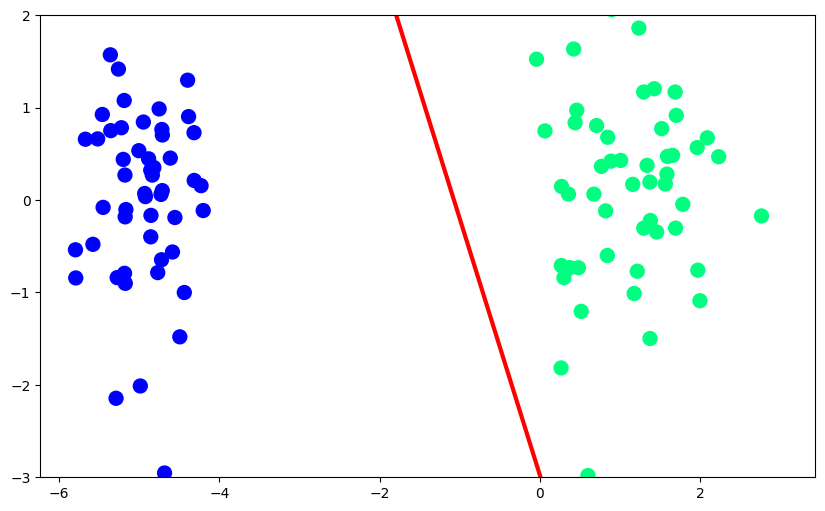

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [ ]:
def perceptron(X,y):

    m = []
    b = []

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.25

    for i in range(100):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))

    return m,b

In [ ]:
m,b = perceptron(X,y)


In [ ]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation


In [ ]:
!pip install celluloid

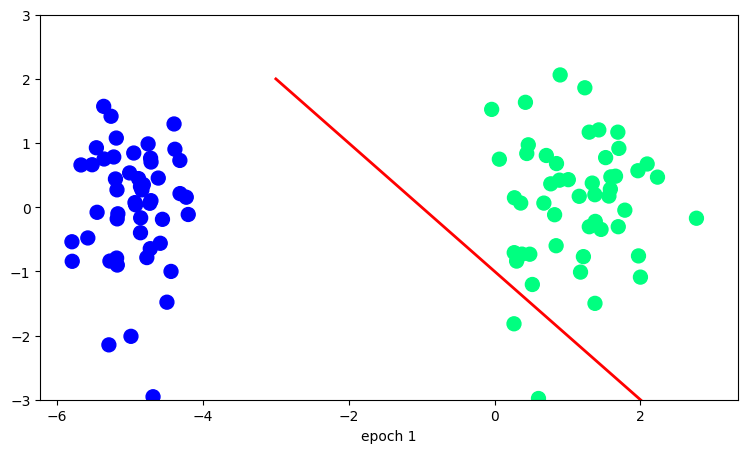

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)    #sets y axis to -3,3
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax
anim = FuncAnimation(fig, update, repeat=True, frames=100, interval=100)
anim.save('/content/logistic_regresion_animation.gif')

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_model = LogisticRegression(panalty="l1")

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'panalty'

In [ ]:
lr_model.fit(X, y)

In [ ]:
print(lr_model.coef_)
print(lr_model.intercept_)

In [ ]:
m = - (lr_model.coef_[0][0]) / (lr_model.coef_[0][1])
b= - (lr_model.intercept_) / lr_model.coef_[0][1]

In [ ]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m*x_input1 + b

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)

plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)